# Brudnopis

## metoda eulera

$$
\dot{y}(t) = f(t,y)
$$

$$
y_{n+1} = y(n) + h f(t_n, y_n), \quad t_{n+1} = t_n + h
$$


## Funkcja wykładnicza

Przykład zabawkowy
$$
\dot{x}(t) = e^t
$$

metoda eulera

$$
x_{n+1} = x_n + h x_n, \quad t_{n+1} = t_n + h
$$

rozwiązanie analityczne:

$$
x(t) = e^t
$$

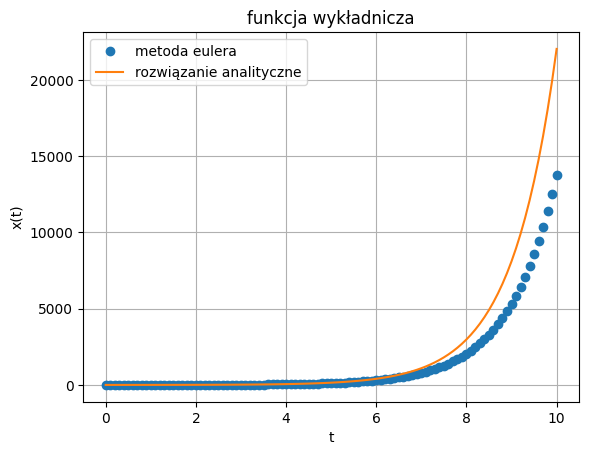

In [32]:
import matplotlib.pyplot as plt
import numpy as np

num_steps = 100
step_size = 0.1

x = np.empty(num_steps + 1)
times = np.empty(num_steps + 1)

x[0] = 1
times[0] = 0

for n in range(num_steps):
    x[n+1] = x[n] + x[n]*step_size
    times[n+1] = times[n] + step_size

plt.figure()
plt.plot(times, x, marker="o", linestyle="")
plt.plot(times, np.exp(times))
plt.title("funkcja wykładnicza")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend(["metoda eulera", "rozwiązanie analityczne"])
plt.grid()
plt.show()

## oscylator harmoniczny
Coś oscyluje na sprężynie. 

parametr $\omega$ opisuje szybkość zmian 


zakładamy że to co oscyluje ma masę jednpstkową, czyli $m = 1$.

$$
E = \frac{1}{2}\dot{x}^2 + \frac{1}{2}\omega^2 x^2
$$

$$
\ddot{x}(t) + \omega^2\dot{x}(t) = 0
$$

## Rozwiązanie oscylatora metodą eulera:


$$
\begin{cases}
\dot{x} = v \\
\dot{v} = -\omega^2x
\end{cases}
$$

$$
\begin{cases}
x_{n+1} = x_n + h v_n\\
v_{n+1} = v_n - h \omega^2 x_n
\end{cases}
$$

### rozwiązanie analityczne
rozwiązanie dla $x(t)$, z warunkami początkowymi $x_0$ i $v_0$.

$$
x(t) = x_0 \cos (\omega t) + \frac{v_0}{\omega} \sin (\omega t)
$$

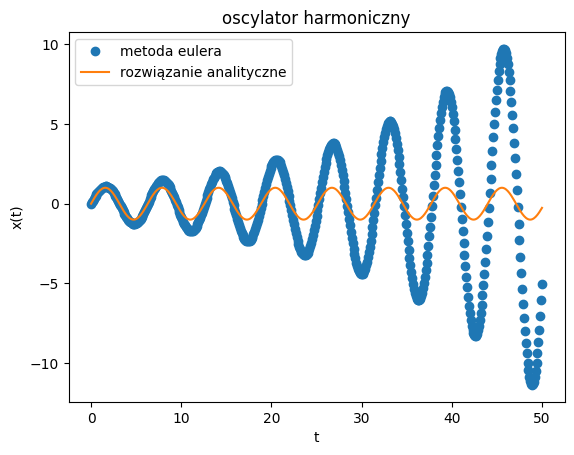

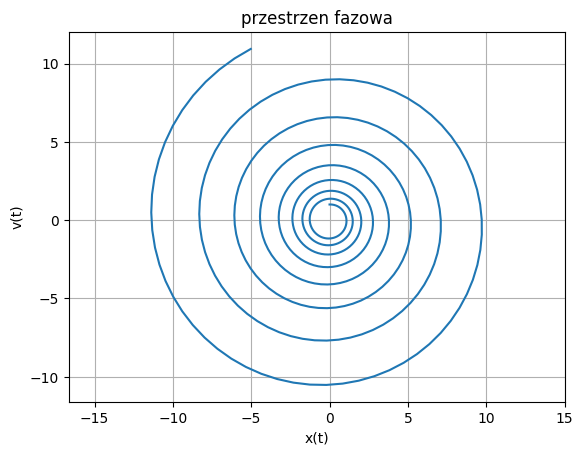

In [38]:
import matplotlib.pyplot as plt
import numpy as np


omega = 1
step_size = 0.1
num_steps = 500


x = np.empty(num_steps + 1)
v = np.empty(num_steps + 1)
times = np.empty(num_steps + 1)

x[0] = 0
v[0] = 1
times[0] = 0

for n in range(num_steps):
    x[n + 1] = x[n] + step_size * v[n]
    v[n + 1] = v[n] - step_size * (omega**2) * x[n]
    times[n+1] = times[n] + step_size

def analitical_solution(t):
    return x[0] * np.cos(omega * t) + v[0]/omega * np.sin(omega * t)

plt.figure()
plt.plot(times, x,  marker="o", linestyle="")
plt.plot(times, analitical_solution(times))
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend(["metoda eulera", "rozwiązanie analityczne"])
plt.title("oscylator harmoniczny")
plt.show()

plt.figure()
plt.plot(x, v)
plt.xlabel("x(t)")
plt.ylabel("v(t)")
plt.title("przestrzen fazowa")
plt.axis("equal")
plt.grid(True)
plt.show()

### dlaczego eksploduje?


$$
E = \frac{1}{2}\dot{x}^2 + \frac{1}{2}\omega^2 x^2 = \frac{1}{2} (v^2 + \omega^2 x^2) = \mathrm{const}
$$

$$
E_n = \frac{1}{2} (v_n^2 + \omega^2 x_n^2)
$$

Podstawiając krok eulera i rozwiązując mamy:

$$
E_{n+1} = (1 + h^2\omega^2) E_n 
$$

$1 + h^2\omega^2 > 1$ dla każdego $h>0$ więc energia rośnie w każdym kroku.


## metoda symplektyczna eulera

Mówimy symplektyczna, bo zachowóje pola w przestrzeni fazowej (zachowuje geometrię symplektyczną). 

$$
\begin{cases}
v_{n+1} = v_n - h \omega^2 x_n\\
x_{n+1} = x_n + h v_{n+1}
\end{cases}
$$

Ważna uwaga - energia nie jest idealnie zachowana, ale odchylania są ograniczone z obu stron

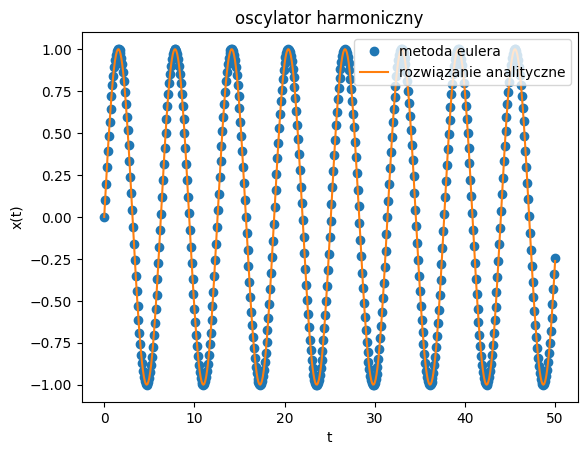

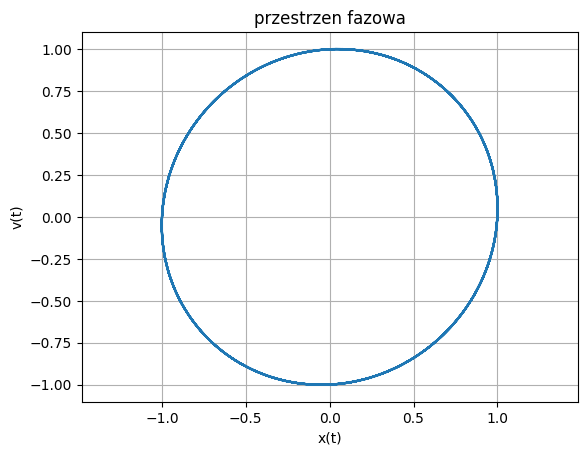

In [40]:
import matplotlib.pyplot as plt
import numpy as np


omega = 1
step_size = 0.1
num_steps = 500


x = np.empty(num_steps + 1)
v = np.empty(num_steps + 1)
times = np.empty(num_steps + 1)

x[0] = 0
v[0] = 1
times[0] = 0
for n in range(num_steps):
    v[n + 1] = v[n] - step_size * (omega**2) * x[n]
    x[n + 1] = x[n] + step_size * v[n+1]
    times[n+1] = times[n] + step_size
    

def analitical_solution(t):
    return x[0] * np.cos(omega * t) + v[0]/omega * np.sin(omega * t)

plt.figure()
plt.plot(times, x,  marker="o", linestyle="")
plt.plot(times, analitical_solution(times))
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend(["metoda eulera", "rozwiązanie analityczne"], loc=1)
plt.title("oscylator harmoniczny")
plt.show()

plt.figure()
plt.plot(x, v)
plt.xlabel("x(t)")
plt.ylabel("v(t)")
plt.title("przestrzen fazowa")
plt.axis("equal")
plt.grid(True)
plt.show()

### Wyprowadzenie wzoru 

$$
F_s = -kx(t)
$$

$$
F_n = ma \, \Rightarrow \, F_n = m \ddot{x}(t) 
$$

$$
F_n = F_s = -kx(t)
$$

$$
m \ddot{x}(t) = -kx(t)
$$

$$
\ddot{x}(t) + \frac{k}{m}\dot{x}(t) = 0
$$

$$
\omega = \sqrt{\frac{k}{m}}
$$

$$
\ddot{x}(t) + \omega^2\dot{x}(t) = 0
$$

### Zadanie domowe

Oscylator harmoniczny z oporem ruchu

$$
\ddot{x}(t) + 2 \omega \zeta \dot{x}(t) + \omega^2 x(t) = 0
$$

parametr $\zeta$ jest wsółczynnikiem tłumienia i okresla jak oscylacje się wygaszają. Warto zwrócić uwagę że będziemy potrzebowali układu trzech równań by rozwiązać to numerycznie metodą Eulera.

## Bibliografia:
- Leimkuhler B, Reich S., *Simulating Hamiltonian Dynamics*, Cambridge University Press; 2005. 
